# Conditional Evaluation of Machine Learning Portfolio Strategies:
# A Functional Inequality Approach

**Author:** Rudransh Khera  
**Program:** Master of Quantitative Economics, UCLA  
**Advisor:** Professor Zhipeng Liao  
April 2026

---

This notebook applies the functional inequality test of Li, Liao, and Zhou (2025) to evaluate whether ML-based portfolio strategies deliver conditionally superior Sharpe ratios relative to traditional Fama-French factor portfolios, using VIX as the conditioning variable.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, RidgeCV
import lightgbm as lgb

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('colorblind')

DATA_DIR = Path('data/raw')

## 2. CSPA Module

Python implementation of the conditional Sharpe ratio inequality test from Li, Liao, and Zhou (2025). (Ported from the MATLAB replication code)


In [2]:
def legendre_basis(x, k):
    """Orthonormal Legendre polynomial basis on [-1, 1] (cf. basis.m)."""
    x = np.asarray(x).flatten()
    n = len(x)
    R_raw = np.zeros((n, k))
    Psi = np.zeros((n, k))
    if k >= 1:
        R_raw[:, 0] = 1.0; Psi[:, 0] = 1.0
    if k >= 2:
        R_raw[:, 1] = x; Psi[:, 1] = np.sqrt(3) * x
    for m in range(2, k):
        R_raw[:, m] = (2 - 1.0/m) * x * R_raw[:, m-1] - (1 - 1.0/m) * R_raw[:, m-2]
        Psi[:, m] = np.sqrt(2*m + 1) * R_raw[:, m]
    return Psi


def transform_conditioning(x, trans_type=1.5):
    """Transform conditioning variable to [-1, 1] (cf. var_trans.m).
    0=identity, 1=normal CDF, 1.5=log then normal CDF (for VIX), 2=rank."""
    x = np.asarray(x).flatten()
    if trans_type == 0:
        return x.copy()
    elif trans_type == 1:
        z = (x - np.mean(x)) / np.std(x, ddof=1)
        return 2 * stats.norm.cdf(z) - 1
    elif trans_type == 1.5:
        log_x = np.log(x)
        z = (log_x - np.mean(log_x)) / np.std(log_x, ddof=1)
        return 2 * stats.norm.cdf(z) - 1
    elif trans_type == 2:
        ranks = stats.rankdata(x, method='dense')
        u = ranks / len(x)
        a = 2.0 / (u.max() - u.min())
        b = -(u.max() + u.min()) / (u.max() - u.min())
        return a * u + b


def estimate_conditional_variance(Y, P, Q, Q_inv):
    """Shape-constrained conditional variance estimation (cf. Est_func.m, type=2)."""
    n, M = Y.shape
    K = P.shape[1]
    beta_mu = Q_inv @ (P.T @ Y) / n
    e_hat = Y - P @ beta_mu
    epsilon_sq = e_hat ** 2
    beta_sigma = Q_inv @ (P.T @ epsilon_sq) / n
    sigma1_sq = P @ beta_sigma
    cond_var_est = np.zeros((n, M))
    H = Q
    for m in range(M):
        Pu = P * e_hat[:, m:m+1]
        Q_u = Q_inv @ (Pu.T @ Pu / n) @ Q_inv
        numer = np.sum((P @ Q_u) * P, axis=1)
        denom = np.sum((P @ Q_inv) * P, axis=1)
        sigma2_sq = numer / denom
        sig_m = np.min(sigma2_sq) / np.log(n)
        if np.all(sigma1_sq[:, m] > sig_m):
            cond_var_est[:, m] = sigma1_sq[:, m]
        else:
            id_drop = sigma1_sq[:, m] > 3 * sig_m
            A_ineq = -P[~id_drop, :]
            c_ineq = -sig_m * np.ones(np.sum(~id_drop))
            B_m = -(P.T @ epsilon_sq[:, m]) / n
            def obj(b): return 0.5 * b @ H @ b + B_m @ b
            def grad(b): return H @ b + B_m
            cons = []
            if A_ineq.shape[0] > 0:
                cons = [{'type': 'ineq', 'fun': lambda b, A=A_ineq, c=c_ineq: c - A @ b,
                         'jac': lambda b, A=A_ineq: -A}]
            try:
                res = minimize(obj, beta_sigma[:, m].copy(), jac=grad,
                               constraints=cons, method='SLSQP',
                               options={'maxiter': 200, 'ftol': 1e-8, 'disp': False})
                cond_var_est[:, m] = P @ res.x
            except Exception:
                cond_var_est[:, m] = sigma1_sq[:, m]
    cond_var_est = np.maximum(cond_var_est, 1e-10)
    eta = epsilon_sq - cond_var_est
    return cond_var_est, eta


def newey_west_covariance(data, nlag=None, demean=True):
    """Newey-West (Bartlett) HAC covariance estimator (cf. covnw.m)."""
    data = np.asarray(data)
    T = data.shape[0]
    if nlag is None:
        nlag = int(np.floor(min(1.2 * T ** (1/3), T)))
    if demean:
        data = data - data.mean(axis=0, keepdims=True)
    w = (nlag + 1 - np.arange(nlag + 1)) / (nlag + 1)
    V = data.T @ data / T
    for i in range(1, nlag + 1):
        Gamma_i = data[i:].T @ data[:T-i] / T
        V = V + w[i] * (Gamma_i + Gamma_i.T)
    return V


def estimate_csr_and_covariance(Y, P, P_grid, Q, Q_inv, cond_var_est, eta, hac_type=0):
    """Estimate conditional Sharpe ratios and covariance matrix Omg_hat,
    accounting for the generated-variable correction (cf. SharpeRatio_CSSR.m)."""
    n, M = Y.shape
    K = P.shape[1]
    J = M - 1
    sigma_hat = np.sqrt(cond_var_est)
    r_star = Y / sigma_hat
    beta_star = Q_inv @ (P.T @ r_star) / n
    epsilon = r_star - P @ beta_star
    CSR_hat_grid = P_grid @ beta_star
    h_hat = CSR_hat_grid[:, 1:] - CSR_hat_grid[:, [0]]
    # Influence function
    P_Jacob = np.hstack([P * (Y[:, j] / (2 * sigma_hat[:, j]**3)).reshape(-1, 1) for j in range(M)])
    Upsilon = (P_Jacob.T @ P / n) @ Q_inv
    part1 = np.hstack([P * epsilon[:, m:m+1] for m in range(M)])
    P_Upsilon_T = P @ Upsilon.T
    eta_exp = np.zeros((n, M * K))
    for m in range(M):
        eta_exp[:, m*K:(m+1)*K] = eta[:, m:m+1]
    P_v = part1 - P_Upsilon_T * eta_exp
    if hac_type == 0:
        Omg_v = P_v.T @ P_v / n
    else:
        Omg_v = newey_west_covariance(P_v)
    K_Q_inv = np.kron(np.eye(M), Q_inv)
    Omg_b = K_Q_inv @ Omg_v @ K_Q_inv
    A2 = np.zeros((J, M)); A2[:, 0] = -1
    for j in range(J): A2[j, j+1] = 1
    L_tilda = np.kron(A2, np.eye(K))
    Omg_hat = L_tilda @ Omg_b @ L_tilda.T
    return h_hat, Omg_hat, beta_star, CSR_hat_grid


def compute_test(h_hat, Omg_hat, P_grid, n, K, alpha=0.05,
                 rho_values=(0.001, 0.005), n_sim=10000, rng_seed=42):
    """Compute the sup-t test statistic and two-step Bonferroni critical values
    (cf. SharpeRatio_CSSR.m)."""
    L, J = h_hat.shape
    sqrt_n = np.sqrt(n)
    rng = np.random.default_rng(rng_seed)
    sigma_x = np.zeros((L, J))
    for j in range(J):
        Omg_jj = Omg_hat[j*K:(j+1)*K, j*K:(j+1)*K]
        sigma_x[:, j] = np.sqrt(np.maximum(np.sum((P_grid @ Omg_jj) * P_grid, axis=1), 0))
    sigma_x = np.maximum(sigma_x, 1e-12)
    studentized = sqrt_n * h_hat / sigma_x
    T_n = max(np.max(studentized), 0.0)
    eigvals, eigvecs = np.linalg.eigh(Omg_hat)
    eigvals = np.maximum(eigvals, 0)
    Omg_sqrt = eigvecs @ np.diag(np.sqrt(eigvals)) @ eigvecs.T
    Z = rng.standard_normal((J * K, n_sim))
    xi = Omg_sqrt @ Z
    Simu_T = np.zeros((L * J, n_sim))
    for j in range(J):
        P_scaled = P_grid / sigma_x[:, j:j+1]
        Simu_T[j*L:(j+1)*L, :] = P_scaled @ xi[j*K:(j+1)*K, :]
    simulated_max = np.max(Simu_T, axis=0)
    LF_cv_5 = np.quantile(simulated_max, 0.95)
    LF_cv_10 = np.quantile(simulated_max, 0.90)
    results_per_rho = []
    for rho in rho_values:
        q_rho = np.quantile(simulated_max, 1 - rho)
        u_hat = np.minimum(h_hat + sigma_x * q_rho / sqrt_n, 0.0)
        adj_term = np.zeros(L * J)
        for j in range(J):
            adj_term[j*L:(j+1)*L] = sqrt_n * u_hat[:, j] / sigma_x[:, j]
        adjusted_max = np.max(Simu_T + adj_term.reshape(-1, 1), axis=0)
        cv_5 = np.quantile(adjusted_max, 0.95 + rho)
        cv_10 = np.quantile(adjusted_max, 0.90 + rho)
        results_per_rho.append({'rho': rho, 'cv_5pct': cv_5, 'cv_10pct': cv_10,
                                'reject_5pct': T_n > cv_5, 'reject_10pct': T_n > cv_10})
    return {'T_n': T_n, 'results': results_per_rho,
            'LF_cv_5pct': LF_cv_5, 'LF_cv_10pct': LF_cv_10,
            'LF_reject_5pct': T_n > LF_cv_5, 'LF_reject_10pct': T_n > LF_cv_10,
            'sigma_x': sigma_x, 'h_hat': h_hat, 'simulated_max': simulated_max}


def run_cspa_test(Y, X, K=6, trans_type=1.5, trim=0.025, alpha=0.05,
                  rho_values=(0.001, 0.005), n_sim=10000, hac_type=0,
                  rng_seed=42, verbose=True):
    """Run the full conditional Sharpe ratio inequality test.
    Y: (n, M) excess returns, col 0 = benchmark, cols 1+ = alternatives.
    X: (n,) conditioning variable (raw VIX values).
    K: sieve dimension, default from max(4, floor(1.2 * n^(1/5))).
    trans_type: 1.5 for VIX (log then normal CDF to [-1,1])."""
    Y = np.asarray(Y); X = np.asarray(X).flatten()
    n, M = Y.shape; J = M - 1
    if verbose:
        print(f'CSPA Test (Li, Liao, Zhou 2025)')
        print(f'  n={n}, M={M} (1 benchmark + {J} alternatives), K={K}')
    X_star = transform_conditioning(X, trans_type=trans_type)
    X_lo = np.quantile(X_star, trim); X_hi = np.quantile(X_star, 1 - trim)
    grid_full = np.linspace(X_star.min(), X_star.max(), 1000)
    grid_x = grid_full[(grid_full >= X_lo) & (grid_full <= X_hi)]
    L = len(grid_x)
    if verbose:
        print(f'  Grid: {L} points on [{X_lo:.3f}, {X_hi:.3f}]')
    P = legendre_basis(X_star, K)
    P_grid = legendre_basis(grid_x, K)
    Q = P.T @ P / n; Q_inv = np.linalg.pinv(Q)
    cond_var_est, eta = estimate_conditional_variance(Y, P, Q, Q_inv)
    h_hat, Omg_hat, beta_star, CSR_grid = estimate_csr_and_covariance(
        Y, P, P_grid, Q, Q_inv, cond_var_est, eta, hac_type=hac_type)
    test_result = compute_test(h_hat, Omg_hat, P_grid, n, K,
                               alpha=alpha, rho_values=rho_values,
                               n_sim=n_sim, rng_seed=rng_seed)
    if verbose:
        print(f'\n  Test statistic T_n = {test_result["T_n"]:.4f}')
        print(f'  Least Favorable: CV(5%)={test_result["LF_cv_5pct"]:.4f}, '
              f'reject={test_result["LF_reject_5pct"]}')
        for res in test_result['results']:
            print(f'  Two-step (rho={res["rho"]}): '
                  f'CV(5%)={res["cv_5pct"]:.4f}, reject={res["reject_5pct"]}')
    test_result.update({'CSR_grid': CSR_grid, 'grid_x': grid_x,
                        'X_star': X_star, 'cond_var_est': cond_var_est,
                        'beta_star': beta_star, 'n': n, 'K': K, 'J': J})
    return test_result


## 3. Data Loading (Daily Frequency)

### 3.1 French Library Data

In [3]:
def load_french_csv(filepath, skiprows=3, freq='monthly'):
    """Load a Fama-French CSV, reading only the first contiguous block of date rows."""
    raw = pd.read_csv(filepath, skiprows=skiprows, header=0)
    raw.columns = raw.columns.str.strip()
    raw = raw.rename(columns={raw.columns[0]: 'date_str'})
    raw['date_str'] = raw['date_str'].astype(str).str.strip()
    if freq == 'monthly':
        pattern = r'^\d{6}$'
        date_fmt = '%Y%m'
    else:
        pattern = r'^\d{8}$'
        date_fmt = '%Y%m%d'
    is_data = raw['date_str'].str.match(pattern)
    first_idx = is_data.idxmax()
    after_first = is_data.loc[first_idx:]
    block_end_candidates = after_first[~after_first]
    if len(block_end_candidates) > 0:
        block_end = block_end_candidates.index[0]
        data = raw.loc[first_idx:block_end - 1].copy()
    else:
        data = raw.loc[first_idx:].copy()
    data['date'] = pd.to_datetime(data['date_str'], format=date_fmt)
    data = data.set_index('date').drop(columns=['date_str'])
    for col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce') / 100.0
    data.index.name = 'date'
    return data

In [4]:
# Loading daily 5 factors
ff5_daily = load_french_csv(
    DATA_DIR / 'F-F_Research_Data_5_Factors_2x3_daily.CSV',
    skiprows=3, freq='daily'
)
ff5_daily.columns = ff5_daily.columns.str.replace('-', '_')
print(f'Daily factors: {ff5_daily.shape}, {ff5_daily.index[0]} to {ff5_daily.index[-1]}')
ff5_daily.head()

Daily factors: (15770, 6), 1963-07-01 00:00:00 to 2026-02-27 00:00:00


,Mkt_RF,SMB,HML,RMW,CMA,RF
date,,,,,,
1963-07-01,-0.0067,0.0000,-0.0034,-0.0001,0.0016,0.0001
1963-07-02,0.0079,-0.0026,0.0026,-0.0007,-0.0020,0.0001
1963-07-03,0.0063,-0.0017,-0.0009,0.0018,-0.0034,0.0001
1963-07-05,0.0040,0.0008,-0.0027,0.0009,-0.0034,0.0001
1963-07-08,-0.0063,0.0004,-0.0018,-0.0029,0.0014,0.0001


In [5]:
# Loading daily 25 portfolios (Size x B/M)
port25_daily = load_french_csv(
    DATA_DIR / '25_Portfolios_5x5_Daily.csv',
    skiprows=18, freq='daily'
)
port25_daily = port25_daily.replace(-0.9999, np.nan).replace(-9.999, np.nan)
print(f'Daily 25 portfolios: {port25_daily.shape}')
port25_daily.head()

Daily 25 portfolios: (26212, 25)


,SMALL LoBM,ME1 BM2,ME1 BM3,ME1 BM4,SMALL HiBM,ME2 BM1,ME2 BM2,ME2 BM3,ME2 BM4,ME2 BM5,...,ME4 BM1,ME4 BM2,ME4 BM3,ME4 BM4,ME4 BM5,BIG LoBM,ME5 BM2,ME5 BM3,ME5 BM4,BIG HiBM
date,,,,,,,,,,,,,,,,,,,,,
1926-07-01,-0.0046,0.0072,0.0085,0.0030,-0.0057,0.0034,0.0173,-0.0002,-0.0055,0.0009,...,0.0000,0.0030,-0.0032,0.0002,0.0041,0.0030,-0.0006,0.0044,-0.0031,0.0040
1926-07-02,0.0057,0.0077,-0.0198,-0.0041,-0.0052,0.0007,-0.0006,-0.0046,-0.0003,0.0040,...,-0.0003,0.0009,0.0104,0.0049,0.0056,0.0050,0.0060,0.0033,0.0051,0.0024
1926-07-06,0.0038,-0.0046,-0.0077,0.0148,-0.0028,-0.0039,-0.0004,0.0035,0.0007,0.0026,...,0.0033,0.0011,0.0079,-0.0011,-0.0044,0.0019,0.0041,-0.0012,-0.0023,0.0033
1926-07-07,-0.0081,-0.0118,0.0126,0.0088,-0.0061,0.0063,-0.0059,-0.0084,-0.0131,-0.0092,...,0.0005,0.0010,0.0015,0.0051,-0.0008,-0.0005,0.0039,0.0009,-0.0016,0.0153
1926-07-08,0.0056,-0.0013,-0.0110,-0.0157,0.0033,0.0049,0.0081,0.0030,0.0017,-0.0052,...,0.0009,0.0036,0.0037,0.0051,0.0127,0.0041,0.0036,0.0001,0.0016,0.0022


In [6]:
# Loading monthly factors and momentum (for ML strategy construction)
ff5_monthly = load_french_csv(DATA_DIR / 'F-F_Research_Data_5_Factors_2x3.CSV', skiprows=3, freq='monthly')
ff5_monthly.columns = ff5_monthly.columns.str.replace('-', '_')
ff5_monthly.index = ff5_monthly.index + pd.offsets.MonthEnd(0)

mom_monthly = load_french_csv(DATA_DIR / 'F-F_Momentum_Factor.CSV', skiprows=13, freq='monthly')
mom_monthly.columns = ['Mom']
mom_monthly.index = mom_monthly.index + pd.offsets.MonthEnd(0)

factors_monthly = ff5_monthly.join(mom_monthly, how='inner')
print(f'Monthly factors: {factors_monthly.shape}')

# Loading monthly 25 portfolios (for ML training)
port25_monthly = load_french_csv(DATA_DIR / '25_Portfolios_5x5.CSV', skiprows=15, freq='monthly')
port25_monthly.index = port25_monthly.index + pd.offsets.MonthEnd(0)
port25_monthly = port25_monthly.replace(-0.9999, np.nan).replace(-9.999, np.nan)
print(f'Monthly 25 portfolios: {port25_monthly.shape}')

Monthly factors: (752, 7)
Monthly 25 portfolios: (1196, 25)


### 3.2 VIX (Daily)

In [7]:
def load_fred(filepath, name):
    raw = pd.read_csv(filepath)
    date_col = [c for c in raw.columns if 'date' in c.lower()][0]
    val_col = [c for c in raw.columns if c != date_col][0]
    raw['date'] = pd.to_datetime(raw[date_col])
    raw[name] = pd.to_numeric(raw[val_col], errors='coerce')
    return raw.set_index('date')[name].dropna()

vix_daily = load_fred(DATA_DIR / 'VIXCLS.csv', 'vix')
print(f'VIX daily: {len(vix_daily)} obs, {vix_daily.index[0]} to {vix_daily.index[-1]}')

VIX daily: 9092 obs, 1990-01-02 00:00:00 to 2025-12-31 00:00:00


### 3.3 Align to Common Daily Sample

In [8]:
# Starting from 1998 (matching the paper's empirical setup)
START = '1998-01-01'

common_daily = (
    ff5_daily.loc[START:].dropna().index
    .intersection(port25_daily.loc[START:].dropna(how='all').index)
    .intersection(vix_daily.loc[START:].dropna().index)
)

ff5_d = ff5_daily.loc[common_daily]
port25_d = port25_daily.loc[common_daily]
vix_d = vix_daily.loc[common_daily]

print(f'Common daily sample: {common_daily[0]} to {common_daily[-1]}')
print(f'n = {len(common_daily)} trading days')
print(f'Recommended K = max(4, floor(1.2 * n^(1/5))) = {max(4, int(np.floor(1.2 * len(common_daily)**(1/5))))}')

Common daily sample: 1998-01-02 00:00:00 to 2025-12-31 00:00:00
n = 7043 trading days
Recommended K = max(4, floor(1.2 * n^(1/5))) = 7


## 4. Traditional Benchmark Strategies (Daily)

In [9]:
trad_daily = pd.DataFrame({
    'Market':    ff5_d['Mkt_RF'],
    'FF3':       ff5_d[['Mkt_RF', 'SMB', 'HML']].mean(axis=1),
    'FF5':       ff5_d[['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA']].mean(axis=1),
    'EqWeight':  port25_d.mean(axis=1),
})

def daily_summary(rets):
    return pd.DataFrame({
        'Ann. Mean':  rets.mean() * 252,
        'Ann. Vol':   rets.std() * np.sqrt(252),
        'Sharpe':     (rets.mean() / rets.std()) * np.sqrt(252),
        'N':          rets.count(),
    }).round(4)

daily_summary(trad_daily)

,Ann. Mean,Ann. Vol,Sharpe,N
Market,0.0884,0.1959,0.4515,7043
FF3,0.0364,0.0891,0.4083,7043
FF5,0.0328,0.0551,0.5958,7043
EqWeight,0.1173,0.2146,0.5468,7043


## 5. ML-Based Portfolio Strategies

ML models are trained monthly on a rolling window. Portfolio weights are held constant within each month, and daily returns are computed from the resulting long-short positions.


In [10]:
def build_monthly_panel(portfolio_returns, factor_data, n_lags=3):
    """Panel dataset for monthly return prediction."""
    port_names = portfolio_returns.columns.tolist()
    dates = portfolio_returns.index
    rows_X, rows_y, rows_info = [], [], []
    for t_pos in range(n_lags + 1, len(dates)):
        date = dates[t_pos]
        for p_idx, port in enumerate(port_names):
            feat = {}
            for lag in range(1, n_lags + 1):
                feat[f'ret_lag{lag}'] = portfolio_returns.iloc[t_pos - lag, p_idx]
            for fcol in factor_data.columns:
                feat[f'f_{fcol}_lag1'] = factor_data[fcol].iloc[t_pos - 1]
            lag1_rets = portfolio_returns.iloc[t_pos - 1, :]
            feat['ret_lag1_rank'] = lag1_rets.rank(pct=True).iloc[p_idx]
            rows_X.append(feat)
            rows_y.append(portfolio_returns.iloc[t_pos, p_idx])
            rows_info.append({'date': date, 'portfolio': port})
    return pd.DataFrame(rows_X), np.array(rows_y), pd.DataFrame(rows_info)


def rolling_ml_weights(X, y, info, port_names, model_type='lasso',
                       train_window=60, n_long=5, n_short=5):
    """Compute monthly long-short weights via rolling-window ML prediction."""
    dates = info['date'].unique()
    def get_model():
        if model_type == 'lasso':
            return Lasso(alpha=0.001, max_iter=5000, random_state=42)
        elif model_type == 'ridge':
            return Ridge(alpha=1.0)
        elif model_type == 'random_forest':
            return RandomForestRegressor(n_estimators=100, max_depth=5,
                                         min_samples_leaf=10, random_state=42, n_jobs=-1)
        elif model_type == 'lightgbm':
            return lgb.LGBMRegressor(n_estimators=100, max_depth=4, learning_rate=0.05,
                                     min_child_samples=20, subsample=0.8,
                                     colsample_bytree=0.8, random_state=42, verbose=-1)
    monthly_weights = {}
    for t in tqdm(range(train_window, len(dates)), desc=model_type):
        test_date = dates[t]
        train_dates = dates[t - train_window:t]
        train_mask = info['date'].isin(train_dates)
        test_mask = info['date'] == test_date
        X_tr = X.loc[train_mask].values
        y_tr = y[train_mask]
        X_te = X.loc[test_mask].values
        if np.any(np.isnan(X_tr)) or np.any(np.isnan(y_tr)):
            continue
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)
        try:
            model = get_model()
            model.fit(X_tr_s, y_tr)
            preds = model.predict(X_te_s)
        except Exception:
            continue
        ranks = pd.Series(preds).rank(ascending=True)
        n_p = len(preds)
        weights = np.zeros(n_p)
        weights[ranks > (n_p - n_long)] = 1.0 / n_long
        weights[ranks <= n_short] = -1.0 / n_short
        monthly_weights[test_date] = weights
    return monthly_weights


def weights_to_daily_returns(monthly_weights, daily_port_returns, port_names):
    """Apply monthly rebalanced weights to daily portfolio returns."""
    daily_strat = pd.Series(index=daily_port_returns.index, dtype=float)
    rebal_dates = sorted(monthly_weights.keys())
    for i, rebal_date in enumerate(rebal_dates):
        if i + 1 < len(rebal_dates):
            next_rebal = rebal_dates[i + 1]
            mask = (daily_port_returns.index > rebal_date) & (daily_port_returns.index <= next_rebal)
        else:
            mask = daily_port_returns.index > rebal_date
        w = monthly_weights[rebal_date]
        daily_rets = daily_port_returns.loc[mask].values
        daily_strat.loc[mask] = daily_rets @ w
    return daily_strat.dropna()

In [11]:
# Building monthly panel for ML training
port25_m = port25_monthly.loc['1990':]
factors_m = factors_monthly.loc['1990':]
common_m = port25_m.dropna(how='all').index.intersection(factors_m.dropna().index)
port25_m = port25_m.loc[common_m]
factors_m = factors_m.loc[common_m]

print('Building monthly panel...')
X_panel, y_panel, info_panel = build_monthly_panel(port25_m, factors_m, n_lags=3)
print(f'Panel: X={X_panel.shape}, y={y_panel.shape}')

# Building ML strategies
TRAIN_WINDOW = 60
port_names = port25_m.columns.tolist()

ml_models = ['lasso', 'ridge', 'random_forest', 'lightgbm']
ml_wts = {}
for m in ml_models:
    ml_wts[m] = rolling_ml_weights(
        X_panel, y_panel, info_panel, port_names,
        model_type=m, train_window=TRAIN_WINDOW
    )

# Converting to daily returns
ml_daily = {}
for m in ml_models:
    ml_daily[m] = weights_to_daily_returns(ml_wts[m], port25_d, port_names)

ml_daily_df = pd.DataFrame(ml_daily)
ml_daily_df.columns = [f'ML_{m}' for m in ml_models]
print(f'ML daily returns: {ml_daily_df.shape}')
daily_summary(ml_daily_df)

Building monthly panel...
Panel: X=(10750, 11), y=(10750,)


lightgbm: 100%|██████████| 370/370 [00:06<00:00, 54.27it/s]


ML daily returns: (7043, 4)


,Ann. Mean,Ann. Vol,Sharpe,N
ML_lasso,-0.0009,0.1202,-0.0079,7043
ML_ridge,0.0070,0.1153,0.0610,7043
ML_random_forest,0.0008,0.1470,0.0054,7043
ML_lightgbm,-0.0165,0.1223,-0.1348,7043


## 6. Exploratory Analysis

In [12]:
import gc
gc.collect()

# Verifying index types before joining
print(f'ml_daily_df index type: {type(ml_daily_df.index).__name__}')
print(f'ml_daily_df index dtype: {ml_daily_df.index.dtype}')
print(f'trad_daily index dtype: {trad_daily.index.dtype}')
print(f'ml_daily_df shape: {ml_daily_df.shape}')
print(f'trad_daily shape: {trad_daily.shape}')

ml_daily_df.index = pd.to_datetime(ml_daily_df.index)


ml_daily_df index type: DatetimeIndex
ml_daily_df index dtype: datetime64[ns]
trad_daily index dtype: datetime64[ns]
ml_daily_df shape: (7043, 4)
trad_daily shape: (7043, 4)


In [13]:
# Aligning all series to common daily index
common_all = (
    trad_daily.index
    .intersection(ml_daily_df.index)
    .intersection(vix_d.index)
)
common_all = common_all.sort_values()

all_daily = pd.concat([trad_daily.loc[common_all], ml_daily_df.loc[common_all]], axis=1)
all_daily = all_daily.dropna()
vix_aligned = vix_d.loc[all_daily.index]

print(f'Aligned sample: {all_daily.index[0]} to {all_daily.index[-1]}, n={len(all_daily)} days')
daily_summary(all_daily)

Aligned sample: 1998-01-02 00:00:00 to 2025-12-31 00:00:00, n=7043 days


,Ann. Mean,Ann. Vol,Sharpe,N
Market,0.0884,0.1959,0.4515,7043
FF3,0.0364,0.0891,0.4083,7043
FF5,0.0328,0.0551,0.5958,7043
EqWeight,0.1173,0.2146,0.5468,7043
ML_lasso,-0.0009,0.1202,-0.0079,7043
ML_ridge,0.0070,0.1153,0.0610,7043
ML_random_forest,0.0008,0.1470,0.0054,7043
ML_lightgbm,-0.0165,0.1223,-0.1348,7043


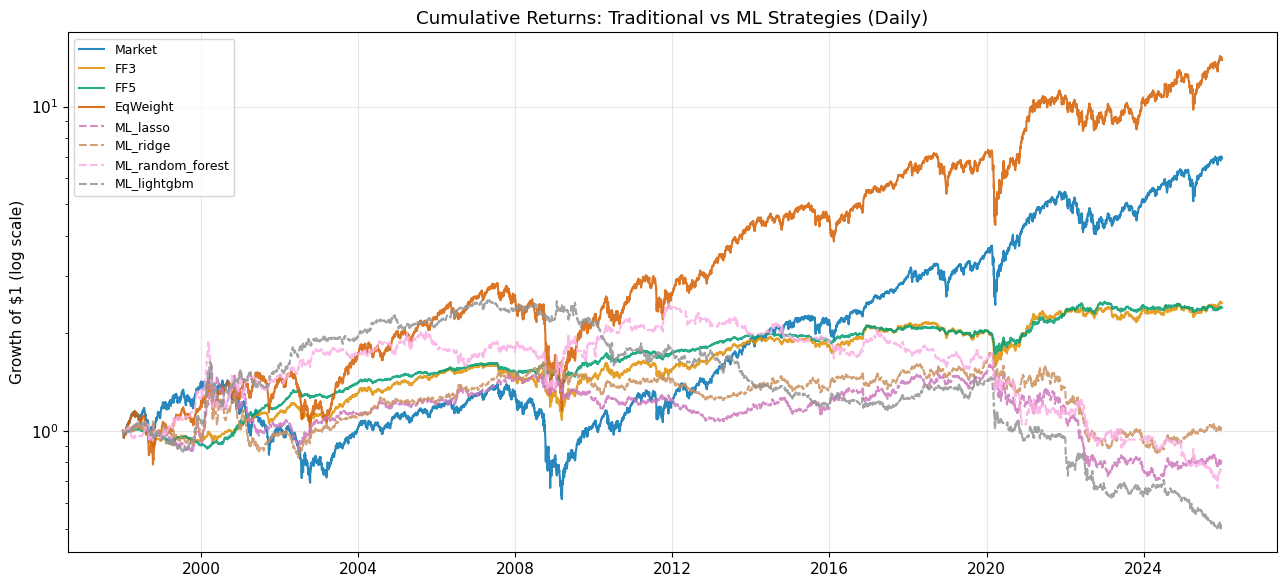

In [14]:
fig, ax = plt.subplots(figsize=(13, 6))
for col in all_daily.columns:
    cum = (1 + all_daily[col]).cumprod()
    ls = '--' if col.startswith('ML_') else '-'
    ax.plot(cum.index, cum.values, label=col, linestyle=ls, alpha=0.85)
ax.set_yscale('log')
ax.set_ylabel('Growth of $1 (log scale)')
ax.set_title('Cumulative Returns: Traditional vs ML Strategies (Daily)')
ax.legend(loc='upper left', fontsize=9)
fig.tight_layout()
plt.show()
fig.savefig('cumulative_returns.pdf', dpi=150, bbox_inches='tight')

## 7. Main CSPA Tests

Conditioning on log(VIX), Legendre basis with K chosen by the rate-optimal rule, two-step Bonferroni critical values with rho in {0.001, 0.005}.


In [15]:
n_days = len(common_all)
K_opt = max(4, int(np.floor(1.2 * n_days ** (1/5))))
print(f'n = {n_days}, K = {K_opt}')

ml_cols = [c for c in all_daily.columns if c.startswith('ML_')]
ml_returns = all_daily[ml_cols].values
vix_vals = vix_aligned.values

n = 7043, K = 7


In [16]:
# Test 1: Market benchmark vs all ML strategies
print('=' * 60)
print('TEST 1: Market vs ML | VIX conditioning')
print('=' * 60)
Y_test1 = np.column_stack([all_daily['Market'].values, ml_returns])
result1 = run_cspa_test(Y=Y_test1, X=vix_vals, K=K_opt, trans_type=1.5,
                        trim=0.025, n_sim=10000, hac_type=0)

TEST 1: Market vs ML | VIX conditioning
CSPA Test (Li, Liao, Zhou 2025)
  n=7043, M=5 (1 benchmark + 4 alternatives), K=7
  Grid: 950 points on [-0.892, 0.972]

  Test statistic T_n = 2.3368
  Least Favorable: CV(5%)=3.0129, reject=False
  Two-step (rho=0.001): CV(5%)=3.0100, reject=False
  Two-step (rho=0.005): CV(5%)=3.0327, reject=False


In [17]:
# Test 2: FF5 benchmark vs all ML strategies
print('=' * 60)
print('TEST 2: FF5 vs ML | VIX conditioning')
print('=' * 60)
Y_test2 = np.column_stack([all_daily['FF5'].values, ml_returns])
result2 = run_cspa_test(Y=Y_test2, X=vix_vals, K=K_opt, trans_type=1.5,
                        trim=0.025, n_sim=10000, hac_type=0)

TEST 2: FF5 vs ML | VIX conditioning
CSPA Test (Li, Liao, Zhou 2025)
  n=7043, M=5 (1 benchmark + 4 alternatives), K=7
  Grid: 950 points on [-0.892, 0.972]

  Test statistic T_n = 2.5208
  Least Favorable: CV(5%)=3.0423, reject=False
  Two-step (rho=0.001): CV(5%)=3.0480, reject=False
  Two-step (rho=0.005): CV(5%)=3.0729, reject=False


In [18]:
# Test 3: EqWeight benchmark vs all ML strategies
print('=' * 60)
print('TEST 3: EqWeight vs ML | VIX conditioning')
print('=' * 60)
Y_test3 = np.column_stack([all_daily['EqWeight'].values, ml_returns])
result3 = run_cspa_test(Y=Y_test3, X=vix_vals, K=K_opt, trans_type=1.5,
                        trim=0.025, n_sim=10000, hac_type=0)

TEST 3: EqWeight vs ML | VIX conditioning
CSPA Test (Li, Liao, Zhou 2025)
  n=7043, M=5 (1 benchmark + 4 alternatives), K=7
  Grid: 950 points on [-0.892, 0.972]

  Test statistic T_n = 2.6749
  Least Favorable: CV(5%)=3.0321, reject=False
  Two-step (rho=0.001): CV(5%)=3.0358, reject=False
  Two-step (rho=0.005): CV(5%)=3.0561, reject=False


In [19]:
# Test 4: Ridge (best ML by Sharpe) as benchmark vs traditional strategies
print('=' * 60)
print('TEST 4: ML_ridge vs Traditional | VIX conditioning')
print('=' * 60)
trad_cols = ['Market', 'FF3', 'FF5', 'EqWeight']
Y_test4 = np.column_stack([all_daily['ML_ridge'].values,
                           all_daily[trad_cols].values])
result4 = run_cspa_test(Y=Y_test4, X=vix_vals, K=K_opt, trans_type=1.5,
                        trim=0.025, n_sim=10000, hac_type=0)

TEST 4: ML_ridge vs Traditional | VIX conditioning
CSPA Test (Li, Liao, Zhou 2025)
  n=7043, M=5 (1 benchmark + 4 alternatives), K=7
  Grid: 950 points on [-0.892, 0.972]

  Test statistic T_n = 3.6681
  Least Favorable: CV(5%)=2.9904, reject=True
  Two-step (rho=0.001): CV(5%)=2.9976, reject=True
  Two-step (rho=0.005): CV(5%)=3.0365, reject=True


In [20]:
# Summary table
summary_rows = []
for label, res in [('Market vs ML', result1), ('FF5 vs ML', result2),
                   ('EqWeight vs ML', result3), ('ML_ridge vs Trad', result4)]:
    row = {'Test': label, 'T_n': res['T_n'],
           'LF_CV': res['LF_cv_5pct'], 'LF_reject': res['LF_reject_5pct']}
    for r in res['results']:
        row[f'CV(rho={r["rho"]})'] = r['cv_5pct']
        row[f'Reject(rho={r["rho"]})'] = r['reject_5pct']
    summary_rows.append(row)
print('\n=== RESULTS SUMMARY (5% level) ===')
pd.DataFrame(summary_rows).round(4)


=== RESULTS SUMMARY (5% level) ===


,Test,T_n,LF_CV,LF_reject,CV(rho=0.001),Reject(rho=0.001),CV(rho=0.005),Reject(rho=0.005)
0,Market vs ML,2.3368,3.0129,False,3.0100,False,3.0327,False
1,FF5 vs ML,2.5208,3.0423,False,3.0480,False,3.0729,False
2,EqWeight vs ML,2.6749,3.0321,False,3.0358,False,3.0561,False
3,ML_ridge vs Trad,3.6681,2.9904,True,2.9976,True,3.0365,True


## 8. Conditional Sharpe Ratio Plots

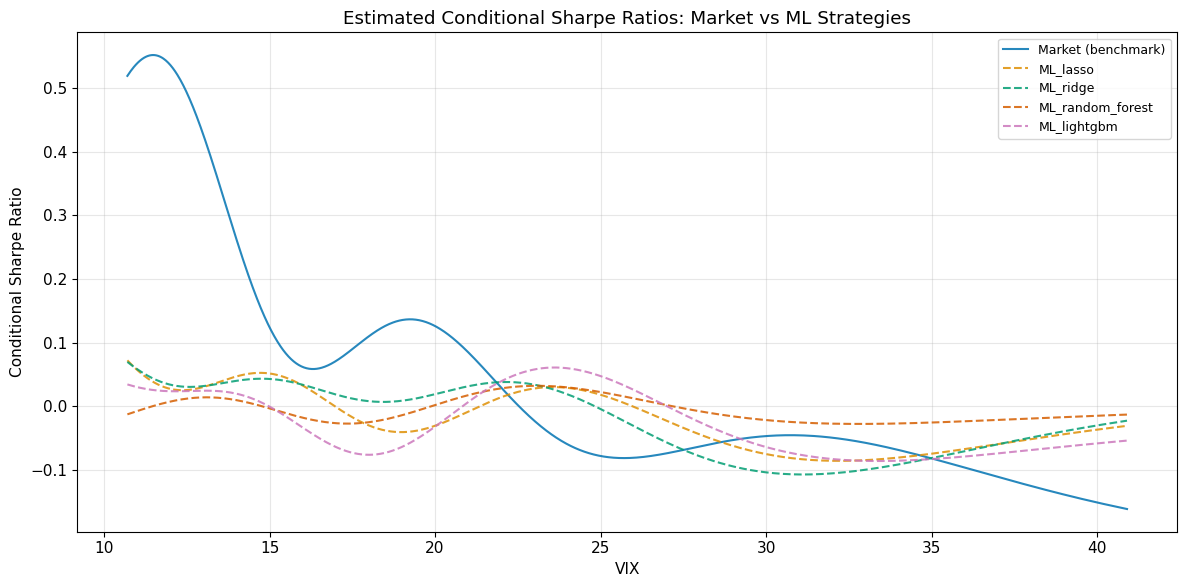

In [21]:
# Plotting conditional Sharpe ratios from Test 1
CSR = result1['CSR_grid']
grid = result1['grid_x']

# Inverting transformation to get VIX scale
log_vix = np.log(vix_vals)
mu_lv, std_lv = np.mean(log_vix), np.std(log_vix, ddof=1)
grid_vix = np.exp(stats.norm.ppf((grid + 1) / 2) * std_lv + mu_lv)

fig, ax = plt.subplots(figsize=(12, 6))
labels = ['Market (benchmark)'] + ml_cols
for j in range(CSR.shape[1]):
    ls = '-' if j == 0 else '--'
    ax.plot(grid_vix, CSR[:, j], label=labels[j], linestyle=ls, alpha=0.85)
ax.set_xlabel('VIX')
ax.set_ylabel('Conditional Sharpe Ratio')
ax.set_title('Estimated Conditional Sharpe Ratios: Market vs ML Strategies')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()
fig.savefig('csr_plot.pdf', dpi=150, bbox_inches='tight')

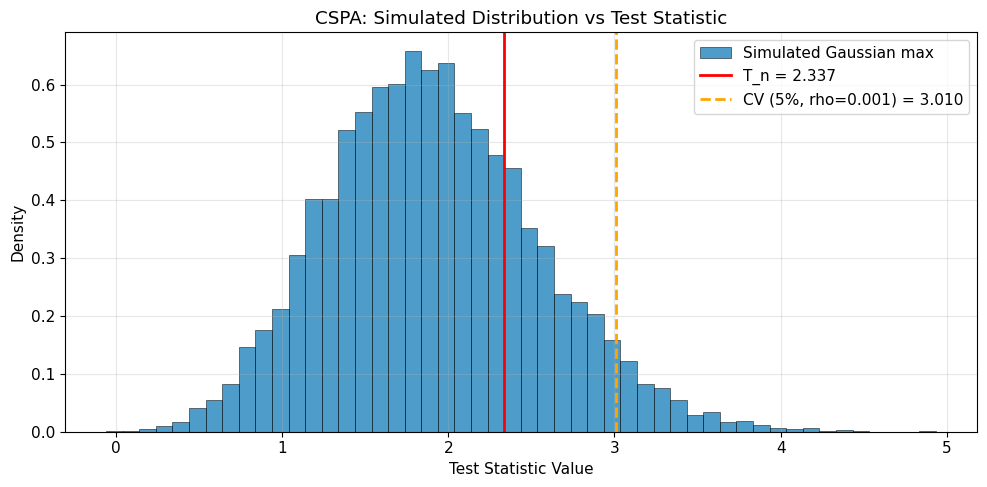

In [22]:
# Simulated distribution vs test statistic
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(result1['simulated_max'], bins=50, density=True,
        alpha=0.7, edgecolor='black', lw=0.5, label='Simulated Gaussian max')
ax.axvline(result1['T_n'], color='red', lw=2, ls='-',
           label=f'T_n = {result1["T_n"]:.3f}')
ax.axvline(result1['results'][0]['cv_5pct'], color='orange', lw=2, ls='--',
           label=f'CV (5%, rho=0.001) = {result1["results"][0]["cv_5pct"]:.3f}')
ax.set_xlabel('Test Statistic Value')
ax.set_ylabel('Density')
ax.set_title('CSPA: Simulated Distribution vs Test Statistic')
ax.legend()
fig.tight_layout()
plt.show()

## 9. Robustness Checks

### 9.1 Pairwise Tests

In [23]:
pairwise = []
for m_name in ml_cols:
    print(f'\n--- Market vs {m_name} ---')
    Y_pw = np.column_stack([all_daily['Market'].values, all_daily[m_name].values])
    res = run_cspa_test(Y_pw, vix_vals, K=K_opt, trans_type=1.5,
                        trim=0.025, n_sim=10000, hac_type=0)
    pairwise.append({'Alt': m_name, 'T_n': res['T_n'],
                     'CV': res['results'][0]['cv_5pct'],
                     'Reject': res['results'][0]['reject_5pct']})
print('\n=== Pairwise Results ===')
pd.DataFrame(pairwise).round(4)


--- Market vs ML_lasso ---
CSPA Test (Li, Liao, Zhou 2025)
  n=7043, M=2 (1 benchmark + 1 alternatives), K=7
  Grid: 950 points on [-0.892, 0.972]

  Test statistic T_n = 1.7088
  Least Favorable: CV(5%)=2.6859, reject=False
  Two-step (rho=0.001): CV(5%)=2.6945, reject=False
  Two-step (rho=0.005): CV(5%)=2.7283, reject=False

--- Market vs ML_ridge ---
CSPA Test (Li, Liao, Zhou 2025)
  n=7043, M=2 (1 benchmark + 1 alternatives), K=7
  Grid: 950 points on [-0.892, 0.972]

  Test statistic T_n = 1.8074
  Least Favorable: CV(5%)=2.6883, reject=False
  Two-step (rho=0.001): CV(5%)=2.6958, reject=False
  Two-step (rho=0.005): CV(5%)=2.7285, reject=False

--- Market vs ML_random_forest ---
CSPA Test (Li, Liao, Zhou 2025)
  n=7043, M=2 (1 benchmark + 1 alternatives), K=7
  Grid: 950 points on [-0.892, 0.972]

  Test statistic T_n = 2.3368
  Least Favorable: CV(5%)=2.6871, reject=False
  Two-step (rho=0.001): CV(5%)=2.6770, reject=False
  Two-step (rho=0.005): CV(5%)=2.7005, reject=False

-

,Alt,T_n,CV,Reject
0,ML_lasso,1.7088,2.6945,False
1,ML_ridge,1.8074,2.6958,False
2,ML_random_forest,2.3368,2.6770,False
3,ML_lightgbm,1.7420,2.6759,False


### 9.2 Sensitivity to Sieve Dimension


In [24]:
sens = []
for K_test in [4, 5, 6, 7, 8]:
    res = run_cspa_test(Y_test1, vix_vals, K=K_test, trans_type=1.5,
                        trim=0.025, n_sim=10000, hac_type=0, verbose=False)
    sens.append({'K': K_test, 'T_n': res['T_n'],
                 'CV': res['results'][0]['cv_5pct'],
                 'Reject': res['results'][0]['reject_5pct']})
    print(f'K={K_test}: T_n={res["T_n"]:.4f}, CV={res["results"][0]["cv_5pct"]:.4f}, '
          f'Reject={res["results"][0]["reject_5pct"]}')
print('\n=== Sensitivity to K ===')
pd.DataFrame(sens).round(4)

K=4: T_n=2.9913, CV=2.7874, Reject=True
K=5: T_n=2.6870, CV=2.8553, Reject=False
K=6: T_n=2.4741, CV=2.9221, Reject=False
K=7: T_n=2.3368, CV=3.0100, Reject=False
K=8: T_n=2.1413, CV=3.0440, Reject=False

=== Sensitivity to K ===


,K,T_n,CV,Reject
0,4,2.9913,2.7874,True
1,5,2.6870,2.8553,False
2,6,2.4741,2.9221,False
3,7,2.3368,3.0100,False
4,8,2.1413,3.0440,False


### 9.3 HAC Covariance

In [25]:
print('Test 1 with Newey-West HAC:')
result1_hac = run_cspa_test(Y_test1, vix_vals, K=K_opt, trans_type=1.5,
                            trim=0.025, n_sim=10000, hac_type=1)

Test 1 with Newey-West HAC:
CSPA Test (Li, Liao, Zhou 2025)
  n=7043, M=5 (1 benchmark + 4 alternatives), K=7
  Grid: 950 points on [-0.892, 0.972]

  Test statistic T_n = 3.1600
  Least Favorable: CV(5%)=3.0016, reject=True
  Two-step (rho=0.001): CV(5%)=3.0095, reject=True
  Two-step (rho=0.005): CV(5%)=3.0296, reject=True


### 9.4 Cross-Validated Tuning for ML Strategies

In [26]:
# Re-run ML strategies with data-dependent regularization selection
# LassoCV and RidgeCV select alpha via 5-fold CV within each rolling window

def rolling_ml_weights_cv(X, y, info, port_names, model_type='lasso_cv',
                          train_window=60, n_long=5, n_short=5):
    """Same rolling-window procedure but with CV-tuned regularization."""
    dates = info['date'].unique()
    def get_model():
        if model_type == 'lasso_cv':
            return LassoCV(cv=5, max_iter=5000, random_state=42)
        elif model_type == 'ridge_cv':
            return RidgeCV(alphas=np.logspace(-3, 3, 20), cv=5)
        elif model_type == 'random_forest':
            return RandomForestRegressor(n_estimators=100, max_depth=5,
                                         min_samples_leaf=10, random_state=42, n_jobs=-1)
        elif model_type == 'lightgbm':
            return lgb.LGBMRegressor(n_estimators=100, max_depth=4, learning_rate=0.05,
                                     min_child_samples=20, subsample=0.8,
                                     colsample_bytree=0.8, random_state=42, verbose=-1)
    monthly_weights = {}
    for t in tqdm(range(train_window, len(dates)), desc=model_type):
        test_date = dates[t]
        train_dates = dates[t - train_window:t]
        train_mask = info['date'].isin(train_dates)
        test_mask = info['date'] == test_date
        X_tr = X.loc[train_mask].values
        y_tr = y[train_mask]
        X_te = X.loc[test_mask].values
        if np.any(np.isnan(X_tr)) or np.any(np.isnan(y_tr)):
            continue
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)
        try:
            model = get_model()
            model.fit(X_tr_s, y_tr)
            preds = model.predict(X_te_s)
        except Exception:
            continue
        ranks = pd.Series(preds).rank(ascending=True)
        n_p = len(preds)
        weights = np.zeros(n_p)
        weights[ranks > (n_p - n_long)] = 1.0 / n_long
        weights[ranks <= n_short] = -1.0 / n_short
        monthly_weights[test_date] = weights
    return monthly_weights

# CV-tuned models
cv_models = ['lasso_cv', 'ridge_cv', 'random_forest', 'lightgbm']
cv_wts = {}
for m in cv_models:
    cv_wts[m] = rolling_ml_weights_cv(
        X_panel, y_panel, info_panel, port_names,
        model_type=m, train_window=TRAIN_WINDOW
    )

# Convert to daily returns
cv_daily = {}
for m in cv_models:
    cv_daily[m] = weights_to_daily_returns(cv_wts[m], port25_d, port_names)

cv_daily_df = pd.DataFrame(cv_daily)
cv_daily_df.columns = [f'CV_{m}' for m in cv_models]
cv_daily_df.index = pd.to_datetime(cv_daily_df.index)

print(f'CV-tuned ML daily returns: {cv_daily_df.shape}')
daily_summary(cv_daily_df)

lightgbm: 100%|██████████| 370/370 [00:06<00:00, 53.93it/s]


CV-tuned ML daily returns: (7043, 4)


,Ann. Mean,Ann. Vol,Sharpe,N
CV_lasso_cv,-0.0193,0.0596,-0.3246,7043
CV_ridge_cv,0.0081,0.1198,0.0673,7043
CV_random_forest,0.0008,0.1470,0.0054,7043
CV_lightgbm,-0.0165,0.1223,-0.1348,7043


In [27]:
# CSPA test: Market vs CV-tuned ML strategies
cv_cols = cv_daily_df.columns.tolist()
common_cv = (
    trad_daily.index
    .intersection(cv_daily_df.dropna().index)
    .intersection(vix_d.dropna().index)
).sort_values()

trad_cv = trad_daily.loc[common_cv]
ml_cv = cv_daily_df.loc[common_cv]
vix_cv = vix_d.loc[common_cv]

print(f'CV-tuned aligned sample: n={len(common_cv)} days')

Y_cv = np.column_stack([trad_cv['Market'].values, ml_cv.values])

print('\n' + '=' * 60)
print('Market vs CV-tuned ML | VIX conditioning')
print('=' * 60)
result_cv = run_cspa_test(
    Y=Y_cv, X=vix_cv.values,
    K=K_opt, trans_type=1.5, trim=0.025,
    n_sim=10000, hac_type=0,
)

# Side-by-side comparison
print('\n=== Fixed vs CV-Tuned Comparison ===')
comparison = pd.DataFrame({
    'Fixed Sharpe': {
        'LASSO': all_daily['ML_lasso'].mean() / all_daily['ML_lasso'].std() * np.sqrt(252),
        'Ridge': all_daily['ML_ridge'].mean() / all_daily['ML_ridge'].std() * np.sqrt(252),
        'RF': all_daily['ML_random_forest'].mean() / all_daily['ML_random_forest'].std() * np.sqrt(252),
        'LightGBM': all_daily['ML_lightgbm'].mean() / all_daily['ML_lightgbm'].std() * np.sqrt(252),
    },
    'CV Sharpe': {
        'LASSO': ml_cv['CV_lasso_cv'].mean() / ml_cv['CV_lasso_cv'].std() * np.sqrt(252),
        'Ridge': ml_cv['CV_ridge_cv'].mean() / ml_cv['CV_ridge_cv'].std() * np.sqrt(252),
        'RF': ml_cv['CV_random_forest'].mean() / ml_cv['CV_random_forest'].std() * np.sqrt(252),
        'LightGBM': ml_cv['CV_lightgbm'].mean() / ml_cv['CV_lightgbm'].std() * np.sqrt(252),
    },
})
comparison['Difference'] = comparison['CV Sharpe'] - comparison['Fixed Sharpe']

print(comparison.round(4))
print(f'\nFixed test:  T_n={result1["T_n"]:.4f}, reject={result1["results"][0]["reject_5pct"]}')
print(f'CV test:     T_n={result_cv["T_n"]:.4f}, reject={result_cv["results"][0]["reject_5pct"]}')

CV-tuned aligned sample: n=7043 days

Market vs CV-tuned ML | VIX conditioning
CSPA Test (Li, Liao, Zhou 2025)
  n=7043, M=5 (1 benchmark + 4 alternatives), K=7
  Grid: 950 points on [-0.892, 0.972]

  Test statistic T_n = 2.9653
  Least Favorable: CV(5%)=3.0562, reject=False
  Two-step (rho=0.001): CV(5%)=3.0534, reject=False
  Two-step (rho=0.005): CV(5%)=3.0669, reject=False

=== Fixed vs CV-Tuned Comparison ===
          Fixed Sharpe  CV Sharpe  Difference
LASSO          -0.0079    -0.3246     -0.3167
Ridge           0.0610     0.0673      0.0063
RF              0.0054     0.0054      0.0000
LightGBM       -0.1348    -0.1348      0.0000

Fixed test:  T_n=2.3368, reject=False
CV test:     T_n=2.9653, reject=False


## 10. Further Analysis

## CSMS

In [28]:
# Confidence Set for the Most Superior (CSMS)
# Rotate benchmark across all strategies; mark non-rejections with checkmarks.
# Mirrors Table 3 of Li, Liao, Zhou (2025).

all_strategy_names = ['Market', 'FF3', 'FF5', 'EqWeight',
                      'ML_lasso', 'ML_ridge', 'ML_random_forest', 'ML_lightgbm']

csms_results = []

for bench_name in all_strategy_names:
    alt_names = [s for s in all_strategy_names if s != bench_name]
    Y_csms = np.column_stack([
        all_daily[bench_name].values,
        all_daily[alt_names].values
    ])
    
    print(f'\n--- Benchmark: {bench_name} ---')
    res = run_cspa_test(Y=Y_csms, X=vix_vals, K=K_opt, trans_type=1.5,
                        trim=0.025, n_sim=10000, hac_type=0, verbose=False)
    
    reject = res['results'][0]['reject_5pct']
    csms_results.append({
        'Strategy': bench_name,
        'T_n': res['T_n'],
        'CV': res['results'][0]['cv_5pct'],
        'In CSMS': 'No' if reject else 'Yes',
    })
    print(f'  T_n={res["T_n"]:.4f}, CV={res["results"][0]["cv_5pct"]:.4f}, '
          f'reject={reject}')

print('\n=== Confidence Set for the Most Superior ===')
csms_df = pd.DataFrame(csms_results)
csms_df


--- Benchmark: Market ---
  T_n=3.3976, CV=3.1808, reject=True

--- Benchmark: FF3 ---
  T_n=4.0411, CV=3.2420, reject=True

--- Benchmark: FF5 ---
  T_n=3.5152, CV=3.2437, reject=True

--- Benchmark: EqWeight ---
  T_n=3.1979, CV=3.2116, reject=False

--- Benchmark: ML_lasso ---
  T_n=3.3763, CV=3.2321, reject=True

--- Benchmark: ML_ridge ---
  T_n=3.6681, CV=3.2315, reject=True

--- Benchmark: ML_random_forest ---
  T_n=4.9705, CV=3.1932, reject=True

--- Benchmark: ML_lightgbm ---
  T_n=4.7981, CV=3.2074, reject=True

=== Confidence Set for the Most Superior ===


,Strategy,T_n,CV,In CSMS
0,Market,3.397571,3.180802,No
1,FF3,4.041112,3.241972,No
2,FF5,3.515158,3.243703,No
3,EqWeight,3.197866,3.211602,Yes
4,ML_lasso,3.376305,3.232070,No
5,ML_ridge,3.668097,3.231488,No
6,ML_random_forest,4.970497,3.193166,No
7,ML_lightgbm,4.798119,3.207373,No


## Subsample Analysis

In [29]:
# Subsample analysis: pre-2010 vs post-2010
split_date = '2010-01-01'

for label, mask in [('Pre-2010', all_daily.index < split_date),
                    ('Post-2010', all_daily.index >= split_date)]:
    idx = all_daily.index[mask]
    idx = idx.intersection(vix_aligned.index)
    n_sub = len(idx)
    K_sub = max(4, int(np.floor(1.2 * n_sub ** (1/5))))
    
    Y_sub = np.column_stack([all_daily.loc[idx, 'Market'].values,
                             all_daily.loc[idx, ml_cols].values])
    
    print(f'\n{"="*60}')
    print(f'{label}: n={n_sub}, K={K_sub}')
    print(f'{"="*60}')
    
    run_cspa_test(Y=Y_sub, X=vix_aligned.loc[idx].values,
                  K=K_sub, trans_type=1.5, trim=0.025,
                  n_sim=10000, hac_type=0)


Pre-2010: n=3019, K=5
CSPA Test (Li, Liao, Zhou 2025)
  n=3019, M=5 (1 benchmark + 4 alternatives), K=5
  Grid: 960 points on [-0.917, 0.962]

  Test statistic T_n = 2.7832
  Least Favorable: CV(5%)=2.9110, reject=False
  Two-step (rho=0.001): CV(5%)=2.9191, reject=False
  Two-step (rho=0.005): CV(5%)=2.9502, reject=False

Post-2010: n=4024, K=6
CSPA Test (Li, Liao, Zhou 2025)
  n=4024, M=5 (1 benchmark + 4 alternatives), K=6
  Grid: 954 points on [-0.898, 0.973]

  Test statistic T_n = 1.2017
  Least Favorable: CV(5%)=2.9274, reject=False
  Two-step (rho=0.001): CV(5%)=2.8999, reject=False
  Two-step (rho=0.005): CV(5%)=2.9220, reject=False


## Transaction Cost Adjustment

In [30]:
# Transaction cost adjustment
# Compute monthly turnover for each ML strategy and apply proportional cost

def compute_daily_returns_with_costs(monthly_weights, daily_port_returns, 
                                      port_names, cost_bps=10):
    """Apply proportional transaction costs based on monthly turnover."""
    daily_strat = pd.Series(index=daily_port_returns.index, dtype=float)
    rebal_dates = sorted(monthly_weights.keys())
    
    prev_weights = None
    for i, rebal_date in enumerate(rebal_dates):
        w = monthly_weights[rebal_date]
        
        # Turnover = sum of absolute weight changes
        if prev_weights is not None:
            turnover = np.sum(np.abs(w - prev_weights))
        else:
            turnover = np.sum(np.abs(w))  # initial setup
        
        # Cost for this month (spread across daily returns)
        if i + 1 < len(rebal_dates):
            next_rebal = rebal_dates[i + 1]
            mask = ((daily_port_returns.index > rebal_date) & 
                    (daily_port_returns.index <= next_rebal))
        else:
            mask = daily_port_returns.index > rebal_date
        
        n_days = mask.sum()
        if n_days > 0:
            daily_cost = (cost_bps / 10000) * turnover / n_days
            daily_rets = daily_port_returns.loc[mask].values @ w
            daily_strat.loc[mask] = daily_rets - daily_cost
        
        prev_weights = w.copy()
    
    return daily_strat.dropna()

# Build cost-adjusted ML returns (10 bps)
ml_cost_10 = {}
for m in ml_models:
    ml_cost_10[m] = compute_daily_returns_with_costs(
        ml_wts[m], port25_d, port_names, cost_bps=10)

ml_cost_10_df = pd.DataFrame(ml_cost_10)
ml_cost_10_df.columns = [f'ML_{m}' for m in ml_models]
ml_cost_10_df.index = pd.to_datetime(ml_cost_10_df.index)

print('=== After 10 bps transaction costs ===')
daily_summary(ml_cost_10_df)

# CSPA test with cost-adjusted returns
common_cost = (
    trad_daily.index
    .intersection(ml_cost_10_df.dropna().index)
    .intersection(vix_d.dropna().index)
).sort_values()

Y_cost = np.column_stack([
    trad_daily.loc[common_cost, 'Market'].values,
    ml_cost_10_df.loc[common_cost].values
])

print('\n' + '=' * 60)
print('Market vs ML (10 bps cost) | VIX conditioning')
print('=' * 60)
result_cost = run_cspa_test(
    Y=Y_cost, X=vix_d.loc[common_cost].values,
    K=K_opt, trans_type=1.5, trim=0.025,
    n_sim=10000, hac_type=0)

=== After 10 bps transaction costs ===

Market vs ML (10 bps cost) | VIX conditioning
CSPA Test (Li, Liao, Zhou 2025)
  n=7043, M=5 (1 benchmark + 4 alternatives), K=7
  Grid: 950 points on [-0.892, 0.972]

  Test statistic T_n = 2.2304
  Least Favorable: CV(5%)=3.0133, reject=False
  Two-step (rho=0.001): CV(5%)=2.9965, reject=False
  Two-step (rho=0.005): CV(5%)=3.0209, reject=False


---

## Notes

**Methodology:** Li, J., Liao, Z., and Zhou, W. (2025). A General Test for Functional Inequalities.  
**Sieve basis:** Orthonormal Legendre polynomials on [-1, 1].  
**Conditioning variable:** Log(VIX), mapped to [-1, 1] via normal CDF (trans_type=1.5).  
**Variance estimation:** Shape-constrained via QP to enforce positivity.  
**Critical values:** Two-step Bonferroni with rho in {0.001, 0.005}, 10,000 Gaussian simulations.  
**Evaluation grid:** 950 points, trimmed at the 2.5% and 97.5% quantiles of transformed VIX.
